# Libraries

In [39]:
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

# Generating dataset 

In [6]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    random_state=42,
    centers=4
)

<Axes: >

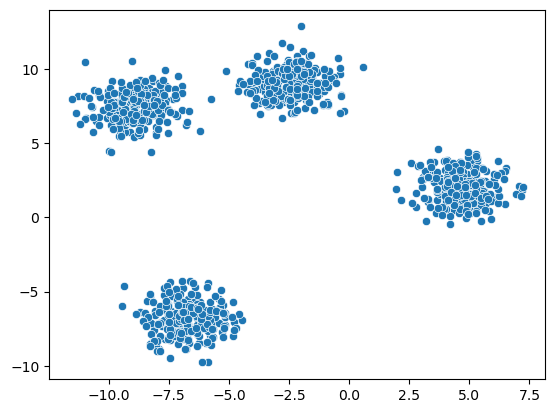

In [7]:
sns.scatterplot(x=X[:,0],
                y=X[:,1])

# K-Means

In [25]:
k = 4
Km = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42,
)

In [26]:
labels = Km.fit_predict(X)

X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<Axes: >

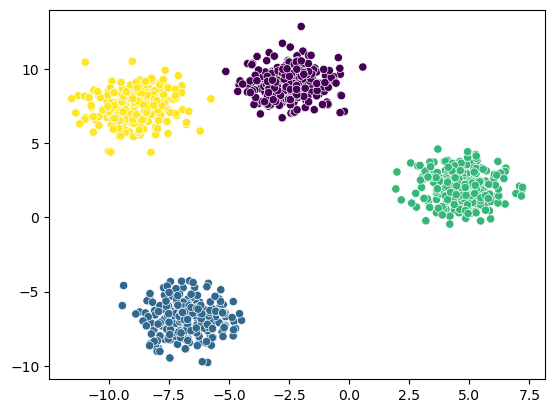

In [27]:
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    c=labels
)

# Choose K value

# Elbow Method

In [28]:
wcss = []
for k in range(1,21):
    Km = KMeans(n_clusters=k)
    Km.fit_predict(X)
    wcss.append(Km.inertia_)


X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

<Axes: >

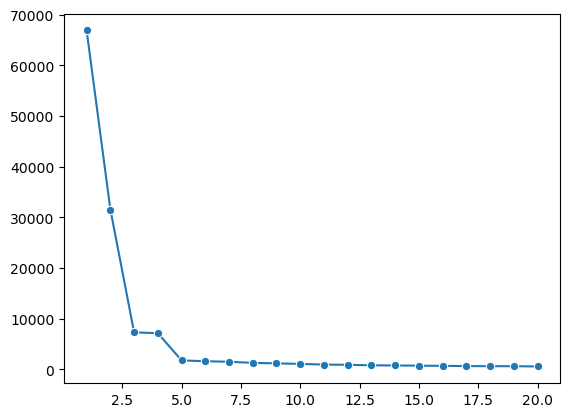

In [31]:
sns.lineplot(
    x=range(1,21),
    y=wcss,
    marker='o'
)

In [38]:
# Kneed Locator
kn = KneeLocator(range(1,21),wcss, curve="convex", direction="decreasing")
print(kn.elbow)

5


# Silhouette score

In [46]:
ss = []
for k in range(2,21):
    Km = KMeans(n_clusters=k)
    labels = Km.fit_predict(X)
    score = silhouette_score(X,labels)
    ss.append(score)
    # print(ss)

X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

<Axes: >

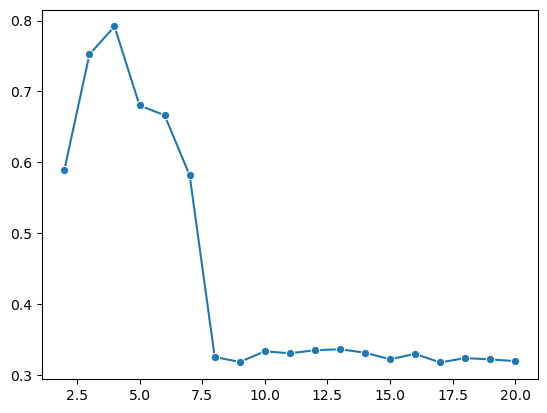

In [48]:
# plot - K and SS
sns.lineplot(x=range(2,21), y=ss, marker='o')

# K-Means for Iris Dataset

In [93]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [71]:
iris = load_iris()
X = iris.data
# X.columns = iris.feature_names
y = iris.target

In [76]:
X.shape

(150, 4)

<Axes: >

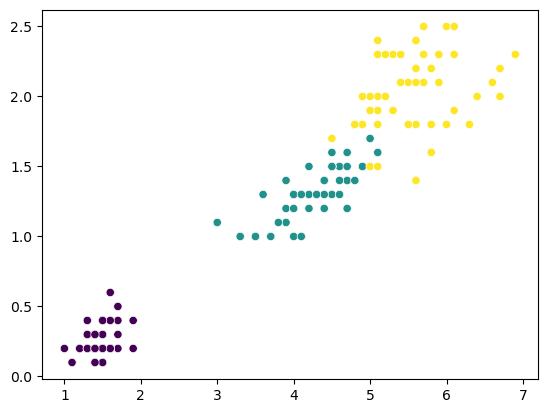

In [92]:
# Visualize
sns.scatterplot(
    x=X[:,2],
    y=X[:,3],
    c=y
)

In [94]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)